# Rome Alésia

## Importations

In [1]:
# LES ALGORITHMES
from QLearning import *
from DQN import *
from PPO import *
import time
import random
from stable_baselines3.common.env_checker import check_env

from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from pathlib import Path
from ray.rllib.core.rl_module import RLModule


# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns
from helperPlot import *

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

## Environnement

Jouer contre opposant jouant complètement aléatoirement

In [2]:
class RomeAlesiaEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaEnv, self).__init__()
        nbUnits = options['nbUnits']
        nbSteps = options['nbSteps']

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = random.randint(1, self.alesiaUnits+1)
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


Jouer contre un joueur humain

In [3]:
class RomeAlesiaPlayerEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaPlayerEnv, self).__init__()
        nbUnits = options['nbUnits']
        nbSteps = options['nbSteps']

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = int(input("Combiens d'unité ? : "))
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


Jouer contre opposant fort

In [4]:
class RomeAlesiaStrongEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaStrongEnv, self).__init__()
        nbUnits = 50
        nbSteps = 2

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = 0

        # État 1 (adjacent à Rome)
        if self.battleFront == 1 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                alesiaAction = self.alesiaUnits
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                temp = np.random.randint(0, 2)
                if temp == 0 : # 50%
                    alesiaAction = self.romeUnits
                else : # 50%
                    alesiaAction = 1
            # Egalite
            else :
                alesiaAction = np.random.randint(self.alesiaUnits-4, self.alesiaUnits-2 + 1)


        # État 2
        if self.battleFront == 2 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                alesiaAction = np.random.randint(self.alesiaUnits - self.romeUnits - 2, self.alesiaUnits - self.romeUnits + 2 + 1)
            # Sinon
            else :
                temp = np.random.randint(0, 4)
                if temp == 0 : # 25%
                    alesiaAction = np.random.randint(1, 4 +1)
                else : # 75%
                    alesiaAction = np.random.randint(6, max(6, self.alesiaUnits//3) +1)

        
        # État 3 (centre)
        if self.battleFront == 3 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                # Suravantage pour Alésia
                if self.alesiaUnits > 2*self.romeUnits :
                    alesiaAction = self.alesiaUnits // 3
                else :
                    alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits // 3)-1) +1)
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                temp = np.random.randint(0, 2)
                if temp == 0 : # 50%
                    alesiaAction = np.random.randint(2, 5 +1)
                else : # 50%
                    alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
            # Égalité
            else :
                alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits//3)-1) +1)

        # État 4
        if self.battleFront == 4 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                temp = np.random.randint(0, 4)
                if temp == 0 :
                    alesiaAction = np.random.randint(2, 5 +1)
                else :
                    alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                alesiaAction = np.random.randint(1, 4)
            # Égalité
            else :
                temp = np.random.randint(0, 2)
                if temp == 0 :
                    alesiaAction = np.random.randint(2, 5 +1)
                else :
                    alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)

        # État 5 (adjacent à Alesia)
        if self.battleFront == 5 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                # Suravantage pour Alésia
                if self.alesiaUnits >= 1.5*self.romeUnits :
                    alesiaAction = self.romeUnits
                elif self.romeUnits < 15 :
                    alesiaAction = self.romeUnits
                else :
                    temp = np.random.randint(0, 2)
                    if temp == 0 :
                        alesiaAction = self.romeUnits
                    else :
                        alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                alesiaAction = self.romeUnits
            # Égalité
            else :
                temp = np.random.randint(0, 2)
                if temp == 0 :
                    alesiaAction = self.romeUnits
                else :
                    alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
        
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


Jouer contre opposant fort avec bruit

In [5]:
class RomeAlesiaRandomOppEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaRandomOppEnv, self).__init__()
        nbUnits = 50
        nbSteps = 2

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits

        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = 0
        # L'opposant à 5% de chance d'effectuer un coup aléatoirement
        exploitation_proba = np.random.random()

        if exploitation_proba < 0.95 :

            # État 1 (adjacent à Rome)
            if self.battleFront == 1 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    alesiaAction = self.alesiaUnits
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    temp = np.random.randint(0, 2)
                    if temp == 0 : # 50%
                        alesiaAction = self.romeUnits
                    else : # 50%
                        alesiaAction = 1
                # Egalite
                else :
                    alesiaAction = np.random.randint(self.alesiaUnits-4, self.alesiaUnits-2 + 1)
    
    
            # État 2
            if self.battleFront == 2 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    alesiaAction = np.random.randint(self.alesiaUnits - self.romeUnits - 2, self.alesiaUnits - self.romeUnits + 2 + 1)
                # Sinon
                else :
                    temp = np.random.randint(0, 4)
                    if temp == 0 : # 25%
                        alesiaAction = np.random.randint(1, 4 +1)
                    else : # 75%
                        alesiaAction = np.random.randint(6, max(6, self.alesiaUnits//3) +1)
    
            
            # État 3 (centre)
            if self.battleFront == 3 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    # Suravantage pour Alésia
                    if self.alesiaUnits > 2*self.romeUnits :
                        alesiaAction = self.alesiaUnits // 3
                    else :
                        alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits // 3)-1) +1)
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    temp = np.random.randint(0, 2)
                    if temp == 0 : # 50%
                        alesiaAction = np.random.randint(2, 5 +1)
                    else : # 50%
                        alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
                # Égalité
                else :
                    alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits//3)-1) +1)
    
            # État 4
            if self.battleFront == 4 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    temp = np.random.randint(0, 4)
                    if temp == 0 :
                        alesiaAction = np.random.randint(2, 5 +1)
                    else :
                        alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    alesiaAction = np.random.randint(1, 4)
                # Égalité
                else :
                    temp = np.random.randint(0, 2)
                    if temp == 0 :
                        alesiaAction = np.random.randint(2, 5 +1)
                    else :
                        alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
    
            # État 5 (adjacent à Alesia)
            if self.battleFront == 5 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    # Suravantage pour Alésia
                    if self.alesiaUnits >= 1.5*self.romeUnits :
                        alesiaAction = self.romeUnits
                    elif self.romeUnits < 15 :
                        alesiaAction = self.romeUnits
                    else :
                        temp = np.random.randint(0, 2)
                        if temp == 0 :
                            alesiaAction = self.romeUnits
                        else :
                            alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    alesiaAction = self.romeUnits
                # Égalité
                else :
                    temp = np.random.randint(0, 2)
                    if temp == 0 :
                        alesiaAction = self.romeUnits
                    else :
                        alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
        else :
            alesiaAction = random.randint(1, self.alesiaUnits+1)
        
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


### Play Against Strong Opponent

In [43]:
done = False
env = RomeAlesiaStrongEnv()
state, _ = env.reset()

while not done :
    env.render()
    romeAction = int(input("Combiens d'unité ? : "))
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  0


R--|--X--M--|--|--A
Rome has 49 units remaining.
Alesia has 46 units remaining.


Combiens d'unité ? :  2


R--X--|--M--|--|--A
Rome has 47 units remaining.
Alesia has 39 units remaining.


...

R--|--|--M--X--|--A
Rome has 7 units remaining.
Alesia has 0 units remaining.


Combiens d'unité ? :  1


R--|--|--M--|--X--A
Rome has 6 units remaining.
Alesia has 0 units remaining.


Combiens d'unité ? :  1


R--|--|--M--|--|--X
Rome has 5 units remaining.
Alesia has 0 units remaining.


### Check classic environment

In [8]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)

check_env(env)

### Get winning chances

In [6]:
def get_win_pourcent(env, model) :
    wins = 0
    for _ in range(10000) :
        state, _ = env.reset()
        done = False
        while not done :
            romeAction = get_best_action(model, state)
            state, _, done, _, _ = env.step(romeAction)
        if env.battleFront == env.alesiaLocation :
            wins += 1

    return (wins / 10000) * 100

## QLearning par défaut

### QLearning par défaut contre joueur aléatoire

Essayons le QLearning par défaut

In [56]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 10000000, useProdForReward = True, maxTimestepsProd = 100)

print("DONE")

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
DONE


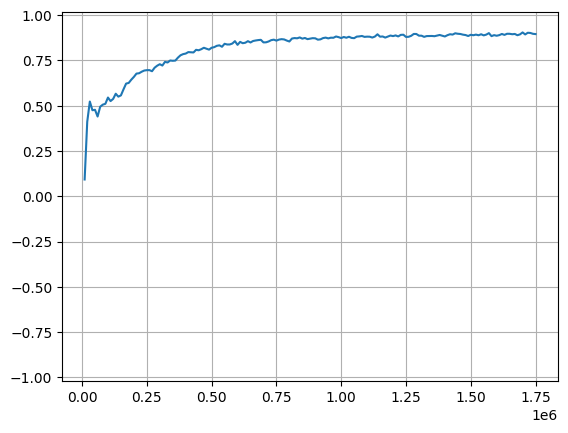

In [57]:
ordo, toPlot = mean_plot(prodReward, 10000)

plt.ylim(-1.02, 1.02)
plt.plot(ordo, toPlot)
plt.grid()
plt.show()

In [17]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(model, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  2


R--|--X--M--|--|--A
Rome has 49 units remaining.
Alesia has 48 units remaining.


Combiens d'unité ? :  2


R--|--|--X--|--|--A
Rome has 19 units remaining.
Alesia has 46 units remaining.


...

R--|--X--M--|--|--A
Rome has 0 units remaining.
Alesia has 32 units remaining.


Combiens d'unité ? :  1


R--X--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 31 units remaining.


Combiens d'unité ? :  1


X--|--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 30 units remaining.


In [58]:
env = RomeAlesiaEnv({'nbUnits' : 50, 'nbSteps' : 2})
print(f"Winning % against random opponent : {get_win_pourcent(env, model)}%")

env = RomeAlesiaStrongEnv()
print(f"Winning % against strong opponent : {get_win_pourcent(env, model)}%")

Winning % against random opponent : 91.8%
Winning % against strong opponent : 2.11%


### QLearning par défaut contre joueur expérimenté

In [24]:
env = RomeAlesiaStrongEnv()
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 10000000, useProdForReward = True, maxTimestepsProd = 100)

print("DONE")

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
DONE


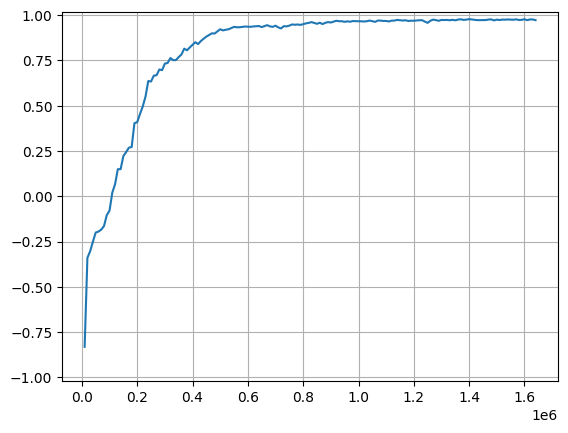

In [45]:
ordo, toPlot = mean_plot(prodReward, 10000)

plt.ylim(-1.02, 1.02)
plt.plot(ordo, toPlot)
plt.grid()
plt.show()

In [39]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(model, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  2


R--|--|--M--X--|--A
Rome has 35 units remaining.
Alesia has 48 units remaining.


Combiens d'unité ? :  2


R--|--|--M--|--X--A
Rome has 20 units remaining.
Alesia has 46 units remaining.


...

R--|--X--M--|--|--A
Rome has 0 units remaining.
Alesia has 23 units remaining.


Combiens d'unité ? :  1


R--X--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 22 units remaining.


Combiens d'unité ? :  1


X--|--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 21 units remaining.


In [55]:
env = RomeAlesiaEnv({'nbUnits' : 50, 'nbSteps' : 2})
print(f"Winning % against random opponent : {get_win_pourcent(env, model)}%")

env = RomeAlesiaStrongEnv()
print(f"Winning % against strong opponent : {get_win_pourcent(env, model)}%")

Winning % against random opponent : 55.15%
Winning % against strong opponent : 98.0%


### Save / Import and Play against model

#### Sauvegarder un model

In [24]:
npModel = np.array(model)

In [25]:
# Pour empêcher les sauvegardes par erreur
#np.save("./model/model100M.npy", npModel)

#### Importer un model

In [26]:
importedModel = np.load("./model/model100M.npy")

#### Jouer contre model importé

In [31]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(importedModel, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
R--|--|--M--X--|--A
Rome has 35 units remaining.
Alesia has 44 units remaining.
R--|--|--M--|--X--A
Rome has 21 units remaining.
Alesia has 33 units remaining.
R--|--|--M--X--|--A
Rome has 19 units remaining.
Alesia has 12 units remaining.
R--|--|--M--|--X--A
Rome has 13 units remaining.
Alesia has 9 units remaining.
R--|--|--M--|--|--X
Rome has 0 units remaining.
Alesia has 0 units remaining.


### Entraînement QLearning contre opposant fort avec bruit

In [15]:
env = RomeAlesiaRandomOppEnv()
env.render()


"""
ATTENTION L'ENTRAÎNEMENT DURE ENVIRON 20 MINUTES

IMPORTER LES MODÈLES DÉJÀ DISPONIBLE AU LIEU DE REFAIRE L'ENTRAÎNEMENT

model.npy : entraîné de cette façon sur 10 millions de steps
model100M.npy : entraîné de cette façon sur 100 millions de steps

"""


# Nombre de steps renseignés : 10 millions

model, reward, prodReward = train_q_learning(env, timesteps = 10000000, useProdForReward = True, maxTimestepsProd = 100)

print("DONE")

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
DONE


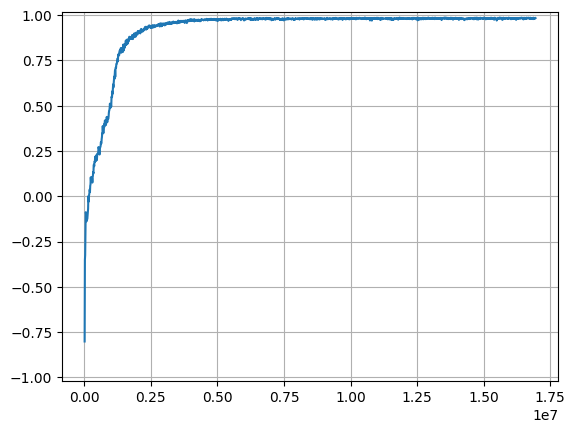

In [16]:
ordo, toPlot = mean_plot(prodReward, 10000)

plt.ylim(-1.02, 1.02)
plt.plot(ordo, toPlot)
plt.grid()
plt.show()

#### Jouer contre l'agent entraîné

In [21]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(model, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  1


R--|--|--M--X--|--A
Rome has 35 units remaining.
Alesia has 49 units remaining.


Combiens d'unité ? :  8


R--|--|--M--|--X--A
Rome has 20 units remaining.
Alesia has 41 units remaining.


...

R--|--X--M--|--|--A
Rome has 0 units remaining.
Alesia has 2 units remaining.


Combiens d'unité ? :  1


R--X--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 1 units remaining.


Combiens d'unité ? :  1


X--|--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 0 units remaining.


#### Évaluation de l'agent

In [32]:
print("Résultats obtenus pour QLearning sur 100 millions de steps")

env = RomeAlesiaEnv({'nbUnits' : 50, 'nbSteps' : 2})
print(f"Winning % against random opponent : {get_win_pourcent(env, model)}%")

env = RomeAlesiaStrongEnv()
print(f"Winning % against strong opponent : {get_win_pourcent(env, model)}%")

Résultats obtenus pour QLearning sur 100 millions de steps
Winning % against random opponent : 90.79%
Winning % against strong opponent : 99.79%


Il n'est pas nécessaire de paramétrer le QLearning puisque par défaut, il au moins environ 90% de victoire sur un entraînement de 100 millions de steps (environ 20 minutes).

Pour l'heure la limitation provient de fait que s'il apprend contre un certain opposant, il ne jouera pas nécessairement de façon optimale face à une autre personne.

## DQN

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


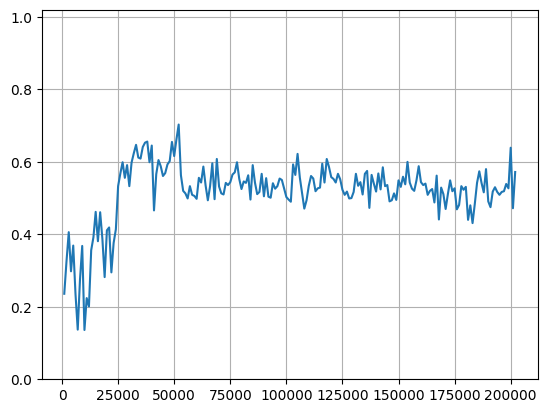

In [19]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                            )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

Mauvais résultats sans paramétrage.

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


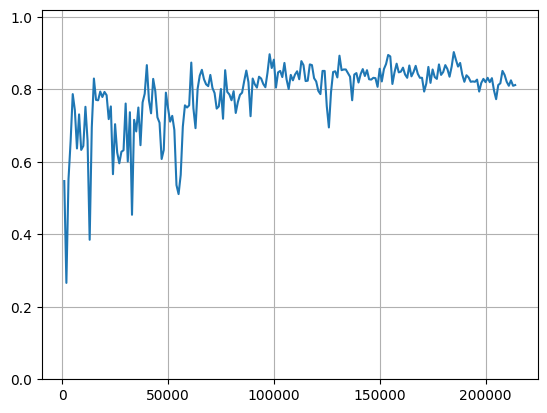

In [20]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                      learning_rate = 0.001, gamma = 0.99, buffer_size = 1000, batch_size = 32,
                                      update_freq = 50, exploration_initial_eps = 1, exploration_final_eps = 0.05,
                                      exploration_fraction = 0.8
                                     )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

Après avoir défini quelques paramètres nous observons un gain de performance.

Il faudrait effectuer un GridSearch pour voir quels résultats nous pourrions obtenir.

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


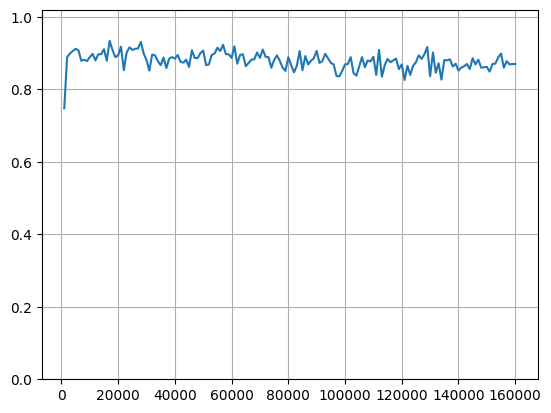

In [21]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                      learning_rate = 0.001, gamma = 0.99, buffer_size = 1000, batch_size = 32,
                                      update_freq = 50, exploration_initial_eps = 0.05, exploration_final_eps = 0.05,
                                      exploration_fraction = 0.8
                                     )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

Configuration trouvée à la main plutôt satisfaisante face à un opposant totalement aléatoire.

# Conclusion problème simple.

Jusqu'à présent, l'objectif est simple :

Avoir un entraînement efficace pour rapidement trouver un comportement qui contre une stratégie fixée.

Nous observons qu'un QLearning correctement configuré sans faire recours à un quelconque changement sur les observations / la distribution des récompenses suffit à obtenir de très bons résultats face à un comportement fixé.

**Ce résultat était anticipé**

En effet, sous réserve que l'opposant ait un comportement fixé (même si ce comportement est probabiliste), RomeAlésia se place dans le cadre théorique du RL (voir rapport pour définition plus précise).

Nous avons donc la garantie que le QLearning converge à partir d'un certain nombre de steps d'entraînement vers un comportement "optimal" (au sens où il maximise le gain en moyenne).

De plus, les cardinalités des espaces d'états et d'actions ne sont pas très élevés, la table Q entre tout à fait dans la mémoire de nos machines et apprendre un comportement efficace n'est pas extrêmement long.

**Est-ce fini pour RomeAlésia ?**

RomeAlésia devient intéressant lorsque l'opposant contre qui vous jouez s'adapte au fil des parties.

En jouant contre un autre joueur humain, vous vous rendrez compte que RomeAlésia peut devenir un jeu de bluff.

Ainsi, prendre en hypothèse le fait que l'opposant ait un comportement fixé (qui n'évolue pas au fil des épisodes) retire ce qui fait de RomeAlésia un jeu intéressant.


On se penche alors sur un problème plus complexe : **et si l'opposant pouvait lui aussi apprendre ?**

# Opposant évolutif

Quelles sont les conséquences de la perte de l'hypothèse : *l'opposant n'évolue pas* ?

La conséquence la plus importante : **Nous ne rentrons plus dans le cadre théorique qui nous garantissait la convergence du QLearning.**


Mais en réalité, c'est encore pire que cela.

Lorsque l'on entraîne un **model avec QLearning ou DQN**, nous obtenons un agent au **comportement déterministe qui n'évolue plus** (puisque l'entraînement est terminé)

## Apprendre comment notre modèle se comporte

Si je suis l'opposant jouant face à notre modèle, je peux utiliser une stratégie très simple pour comprendre comment le modèle joue :

- son comportement est déterministe est n'évolue plus
- donc dans un état fixé, le modèle joue toujours la même chose

Jouons un coup aléatoire pour récupérer la première action de notre modèle, l'action qu'il effectuera dans l'état initial.

In [ ]:
test_q_learning(RomeAlesiaEnv, model, maxTimesteps = 1)

Nous pouvons récupérer ce premier coup.

Nous connaissons donc à l'avance ce qui sera joué par notre modèle, on peut donc jouer la même chose.

#### Second épisode

On peut désormais effectuer un second épisode où l'on commence par la même chose que le modèle.


Imaginons que le modèle commence par jouer n unités, nous connaissons grâce au premier épisode ce nombre n avant de débuter le second épisode.


Rome : le Modèle

Alésia : joueur humain


**MANCHE 1** :

R--|--|--X--|--|--A

Rome : 50

Alésia : 50


Rome joue n

Alésia joue n


**MANCHE 2** : (sous réserve que n < 50)

R--|--|--X--|--|--A

Rome : 50 - n

Alésia : 50 - n

Rome joue n2

Alésia joue aléatoirement

**Quelque soit l'issu de l'épisode 2, nous connaissons désormais n2.**

Pour l'épisode 3, il suffira de jouer n puis n2. Nous connaîtrons alors n3.

Comme les ni sont strictement positifs, à partir d'un certains nombre d'épisode nous pourrons déduire une stratégie qui force l'égalité en jouant la même chose que le modèle jusqu'à épuisement des unités.

## Nous venons de trouver un algorithme

**qui face à tout comportement non évolutif** (qui reste identique entre chaque épisode) **et déterministe** (qui dans un état fixé effectue toujours la même action)

**trouve à partir d'au plus 50 épisodes d'entraînements** (puisque les deux joueurs ont 50 unités)

un **comportement qui force le match nul**

On en déduit que quelque soit l'entraînement suivi par le QLearning ou DQN (quelque soit l'opposant d'entraînement, la sélection des paramètres, etc...), il existe un comportement que l'on peut déterminer par un algorithme en jouant des épisodes et qui force le match nul.

# Comment résoudre ce problème ?

Pour savoir comment le résoudre, il faut comprendre ce qui cause ce problème :

- le comportement du modèle est non évolutif
- le comportement du modèle est déterministe

Voici les deux hypothèses utilisées par notre algorithme qui contre QLearning et DQN.


Il suffit de trouver une façon de retirer l'une de ces hypothèses.

## Avoir un QLearning ou DQN dont le comportement évolue au fil des épisodes ?

En soit QLearning et DQN évoluent mais uniquement au cours de l'entraînement.

Une solution serait donc de **jouer contre QLearning ou DQN pendant l'entraînement** de façon à ce que leur comportement évolue au fil des épisodes.

De cette façon, notre algorithme pour les contrer ne fonctionnerait plus.


**Néanmoins**, cette solution pose des soucis car DQN et QLearning ont besoin de beaucoup de steps pour apprendre (mais en font beaucoup en très peu de secondes !) là où un être humain apprend avec très très peu de steps (mais prend plus de secondes pour effectuer chacune d'entre elles)


Ici puisque le modèle apprend face à l'humain, les deux effectuerons le même nombre de steps et il est quasi-certains que face à QLearning ou DQN l'humain apprendra plus efficacement.

## Un comportement probabiliste non nécessairement déterministe ?

Une solution plus abordable serait que le modèle converge vers un comportement "probabiliste" : qui associe à chaque action une probabilité de l'effectuer et décide selon un tirage.

Or cela n'est pas ce qu'effectue ni QLearning ni DQN.
Il faut se pencher sur d'autres algorithmes qui permettraient à l'issu de l'entraînement d'obtenir un comportement "probabiliste"

# Conclusion

Pour battre un comportement fixé à RomeAlésia, il suffit d'utiliser le QLearning par défaut.

Néanmoins, ni QLearning, ni DQN ne permettrait d'obtenir un modèle capable de battre un humain au cours de multiples épisodes de RomeAlésia